# Beginner Tutorial for Sionna

This notebook follows the tutorial for [Sionna](https://nvlabs.github.io/sionna/phy/tutorials/notebooks/Hello_World.html).



In [62]:
"""
Sionna module carries three names which can be imported:
name in ["phy", "sys", "rt"]
"""

try: 
    import sionna.phy
    import sionna.rt
    import sionna.sys

    # Throwing a faulty sionna import
    # import sionna.rtl

    import sionna

    print("[Import] | Sionna")

except ImportError as e:
    print(e)

# Other necessary imports

import torch
import matplotlib as plt
import numpy as np



[Import] | Sionna


There must be source coming in to the simulation.

In real world, this would be a video file, text message converted to 1s and 0s. In simulation we must generate a stream of bits to act as the payload.

This is done by [BinarySource](https://nvlabs.github.io/sionna/phy/api/mapping/sionna.phy.mapping.BinarySource.html). 

Documented as:

> class sionna.phy.mapping.BinarySource(precision: Literal['single', 'double'] | None = None, device: str | None = None, **kwargs: Any)[source]

* The precision is "single" by default therefore an option representing `real-valued floating-point numbers using 32 bits`, "double" uses 64 bits. [See here.](https://nvlabs.github.io/sionna/phy/api/config.html#sionna.phy.config.Config.precision)

* The device option is a string used for computation e.g., 'cpu', 'cuda:0'.

**Inputs**

shape : 1D tensor/array/list, int. Desired shape of the output tensor.

**Outputs**

bits : shape, *torch.float*. Tensor filled with random binary values

In [63]:
from sionna.phy.mapping import BinarySource

# Without the explicit import, we can also use it as follows:
# source = sionna.phy.mapping.BinarySource()

source = BinarySource()
bits = source([10, 100])

# 10   := number of bits per symbol
# 1000 := number of symbols to generate

print(bits.shape)
print("*" * 60)

print(bits[:0])
print("*" * 60)

print(bits[:1])
print("*" * 60)

print(bits.dtype)
print("*" * 60)

print(bits.device)
print("*" * 60)

# 10 x 100 Array
# print(bits

torch.Size([10, 100])
************************************************************
tensor([], device='cuda:0', size=(0, 100))
************************************************************
tensor([[1., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1.,
         0., 1., 0., 0., 1., 1., 1., 0., 0., 0., 1., 0., 1., 0., 0., 1., 1., 0.,
         1., 0., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0.,
         0., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1., 0., 0., 1., 0., 0., 0.,
         0., 1., 0., 0., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1.,
         0., 0., 1., 1., 0., 0., 0., 1., 1., 0.]], device='cuda:0')
************************************************************
torch.float32
************************************************************
cuda:0
************************************************************


The vector here is simply a sequence or array of numbers. Because the code specifies 10 as the number of bits per symbol; `BinarySource` groups random bits into chunks of 10.

When we print bits, we get an 10 x 100 giant vector.

Radio antennas, however, cannot physically transmit 1s and 0s. Instead they transmit analog radio waves. To send digital data, we have to alter the physical properties of the wave. Specifically its amplitude (height) and phase (timing).

A constellation is the mapping dictionary that tells the hardware exactly how to alter the wave for a specific chunk of bits.

Therefore, now that we have created a BinarySource we should create a `Constellation` for it.

[Constellation](https://nvlabs.github.io/sionna/phy/api/mapping/Constellation.html) is defined as follows:

> class sionna.phy.mapping.Constellation(constellation_type: str, num_bits_per_symbol: int, points: numpy.ndarray | torch.Tensor | None = None, normalize: bool = False, center: bool = False, precision: Literal['single', 'double'] | None = None, device: str | None = None, **kwargs: Any)

This class defines a constellation, a complex-valued vector of constellation points. The binary representation of the index of an element of this vector corresponds to the bit label of the constallation point.

This labeling is used by `Mapper` and `Demapper`.

* constellation_type : ("qam", "pam", "custom")
* num_bits_per_symbol : num of bits per constellation symbol

* normalize (bool) – If True, the constellation is normalized to have unit power. Only applies to custom constellations. Defaults to False.
* center (bool) – If True, the constellation is ensured to have zero mean. Only applies to custom constellations. Defaults to False.

Precision and device are same just like the BinarySource.

**Outputs**

2**num_bits_per_symbol, *torch.complex* and possibly centered and normalized.

In [64]:
from sionna.phy.mapping import Constellation

constellation = Constellation("qam", 4)
points = constellation()

print(points)
print("*" * 60)

print(points.shape)
print("*" * 60)

print(points.dtype)
print("*" * 60)

print(points[:1])
print("*" * 60)

print(points.device)
print("*" * 60)

tensor([ 0.3162+0.3162j,  0.3162+0.9487j,  0.9487+0.3162j,  0.9487+0.9487j,
         0.3162-0.3162j,  0.3162-0.9487j,  0.9487-0.3162j,  0.9487-0.9487j,
        -0.3162+0.3162j, -0.3162+0.9487j, -0.9487+0.3162j, -0.9487+0.9487j,
        -0.3162-0.3162j, -0.3162-0.9487j, -0.9487-0.3162j, -0.9487-0.9487j],
       device='cuda:0')
************************************************************
torch.Size([16])
************************************************************
torch.complex64
************************************************************
tensor([0.3162+0.3162j], device='cuda:0')
************************************************************
cuda:0
************************************************************


Now using the `Constellation` on `BinarySource`.

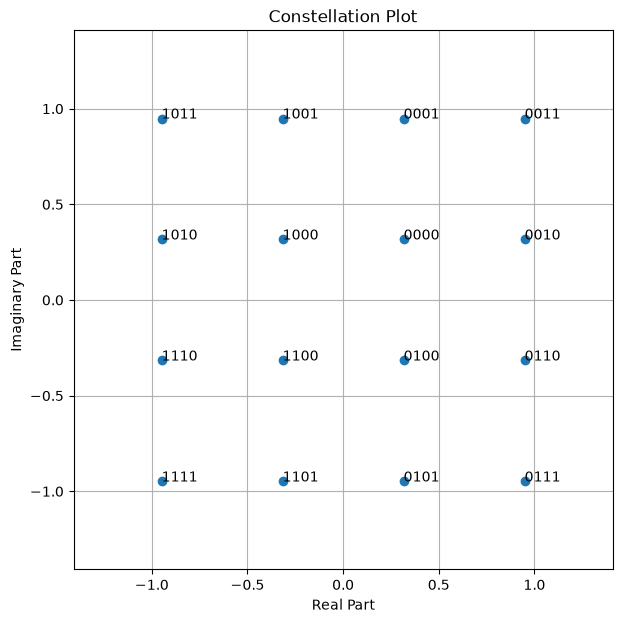

In [65]:
binary_source = BinarySource()

BITS_PER_SYMBOL = 4
BATCH_SIZE = 1000

bits = binary_source([BITS_PER_SYMBOL, BATCH_SIZE])

constellation = Constellation("qam", BITS_PER_SYMBOL)
constellation.show();

Now that we have its bits and the constellation for it, we need to map them together. Therefore, we need a `Mapper` that maps each row of bits to the constellation symbols according to the bit labeling shown.

A [Mapper](https://nvlabs.github.io/sionna/phy/api/mapping/Mapper.html) is defined as follows:

> class sionna.phy.mapping.Mapper(constellation_type: str | None = None, num_bits_per_symbol: int | None = None, constellation: sionna.phy.mapping.Constellation | None = None, return_indices: bool = False, precision: Literal['single', 'double'] | None = None, device: str | None = None, **kwargs: Any)

This class maps binary tensors to points of constellation.

* constellation_type (str | None) – Type of constellation. One of “qam”, “pam”, or “custom”. For “custom”, an instance of Constellation must be provided.

* num_bits_per_symbol (int | None) – The number of bits per constellation symbol, e.g., 4 for QAM16. Only required for constellation_type in [“qam”, “pam”].

* constellation (sionna.phy.mapping.Constellation | None) – If no constellation is provided, constellation_type and num_bits_per_symbol must be provided. Defaults to None.

* return_indices (bool) – If enabled, symbol indices are additionally returned. Defaults to False.

And additionally precision, device are the same.

**Inputs**

bits – […, n], torch.float or torch.int. Tensor with binary entries.

**Outputs**

* x – […, n/Constellation.num_bits_per_symbol], torch.complex. Mapped constellation symbols.

* ind – […, n/Constellation.num_bits_per_symbol], torch.int32. Symbol indices corresponding to the constellation symbols. Only returned if return_indices is set to True.

In [66]:
from sionna.phy.mapping import Mapper

mapper = Mapper(constellation=constellation)
x = mapper(bits)

x[:0]
x[:1]

tensor([[ 0.9487-0.9487j,  0.9487+0.9487j,  0.3162+0.9487j,  0.3162+0.9487j,
         -0.3162-0.9487j,  0.3162-0.9487j,  0.9487-0.3162j,  0.9487+0.9487j,
         -0.9487-0.9487j, -0.3162-0.3162j,  0.3162-0.9487j, -0.9487-0.9487j,
         -0.9487-0.9487j, -0.9487-0.3162j,  0.3162-0.3162j, -0.9487-0.3162j,
         -0.3162-0.9487j, -0.3162+0.3162j,  0.9487+0.9487j,  0.3162+0.3162j,
          0.9487-0.3162j,  0.3162+0.3162j, -0.3162+0.9487j,  0.3162-0.3162j,
         -0.9487-0.3162j, -0.9487+0.9487j,  0.9487+0.9487j, -0.9487+0.9487j,
          0.3162+0.3162j, -0.9487-0.3162j, -0.3162+0.9487j, -0.9487-0.3162j,
         -0.3162+0.9487j,  0.9487-0.3162j,  0.9487+0.9487j, -0.9487-0.9487j,
         -0.3162+0.9487j,  0.3162+0.3162j, -0.3162-0.3162j, -0.9487+0.9487j,
          0.9487-0.9487j,  0.9487-0.9487j,  0.9487-0.9487j,  0.3162+0.9487j,
          0.9487-0.3162j, -0.3162-0.9487j, -0.9487+0.9487j,  0.9487-0.3162j,
         -0.3162-0.3162j,  0.3162+0.3162j,  0.3162-0.3162j,  0.3162-0.9487j,

In addition to this, we can add ***Additive White Gaussian Noise*** (AWGN).

In communication systems, it is the most fundamental mathematical model used to simulate the natural interference that happens when you send a signal through any medium.

* Additive : The noise is simply added to the original signal. If transmitter sends signal x and the universe creates noise n, receiver picks up exactly x + n.

* White : White noise means the interference power is spread completely evenly across all frequencies. The noise does not favor one frequency band over another.

* Gaussian : The amplitude (strength) of the noise follows a normal, bell-curve distribution. Most of the time, the noise is relatively small, but occasionally it spikes.

`AWGN` is defined as:

> class sionna.phy.channel.AWGN(precision: Literal['single', 'double'] | None = None, device: str | None = None, **kwargs)

This class is used to add complex AWGN to the inputs with a certain variance.

**INPUTS**

* x – […], torch.complex. Channel input.
* no – Scalar or Tensor, torch.float. Scalar or tensor whose shape can be broadcast to the shape of x. The noise power no is per complex dimension. If no is a scalar, noise of the same variance will be added to the input. If no is a tensor, it must have a shape that can be broadcast to the shape of x. This allows, e.g., adding noise of different variance to each example in a batch. If no has a lower rank than x, then no will be broadcast to the shape of x by adding dummy dimensions after the last axis.

**OUTPUTS**
* y - tensor with same shape as x, *torch.complex*. Channel output

In [67]:
from sionna.phy.channel import AWGN

awgn_channel = AWGN()

x = torch.randn(64, 16, dtype=torch.complex64)
no = 0.1

y = awgn_channel(x, no)

print(y.shape)
print(y[:1])
print(y.shape)
print(y.dtype)

torch.Size([64, 16])
tensor([[-1.9307-0.8274j, -1.7861-0.1606j,  1.2157+0.2822j,  0.3914+0.0653j,
         -0.0896+1.0414j, -0.2860+0.1587j, -0.0481-0.9360j, -0.3885+0.1648j,
          1.3734-0.6997j, -0.3144+0.5990j,  0.8399-0.2535j, -0.9009+0.3405j,
         -0.0342+0.5443j, -0.1423-0.3627j, -1.3161-0.4515j,  0.5959+0.3281j]],
       device='cuda:0')
torch.Size([64, 16])
torch.complex64


We can additionally compute the noise variance by [`ebnodb2no`](https://nvlabs.github.io/sionna/phy/api/utils/sionna.phy.utils.ebnodb2no.html)

This class computes the noise variance No for a given Eb/No in dB.

* ebno_db (float | torch.Tensor) – Eb/No value in dB.
* num_bits_per_symbol (int) – Number of bits per symbol.
* coderate (float) – Coderate.
* resource_grid (Any | None) – An optional resource grid for OFDM transmissions.

**OUTPUTS**

* no – Value of No in linear scale.

In [68]:
from sionna.phy.utils import ebnodb2no

no = ebnodb2no( ebno_db = 10.0, num_bits_per_symbol=4, coderate=0.5 )

print(no.item())
print(no)
print(no.shape)
print(no.dtype)

0.05000000074505806
tensor(0.0500, device='cuda:0')
torch.Size([])
torch.float32


## Finally Combining Everything

In [72]:
BITS_PER_SYMBOL = 4
BATCH_SIZE = 1000
EBNO_DB = 15

binary_source = BinarySource()
constellation = Constellation("qam", BITS_PER_SYMBOL)
mapper = Mapper(constellation=constellation)
awgn = AWGN()

bits = binary_source([BATCH_SIZE, BITS_PER_SYMBOL])

x = mapper(bits)

no = ebnodb2no(EBNO_DB, BITS_PER_SYMBOL, coderate=1)

y = awgn(x, no).cpu()

Now we can visualize the received signal:

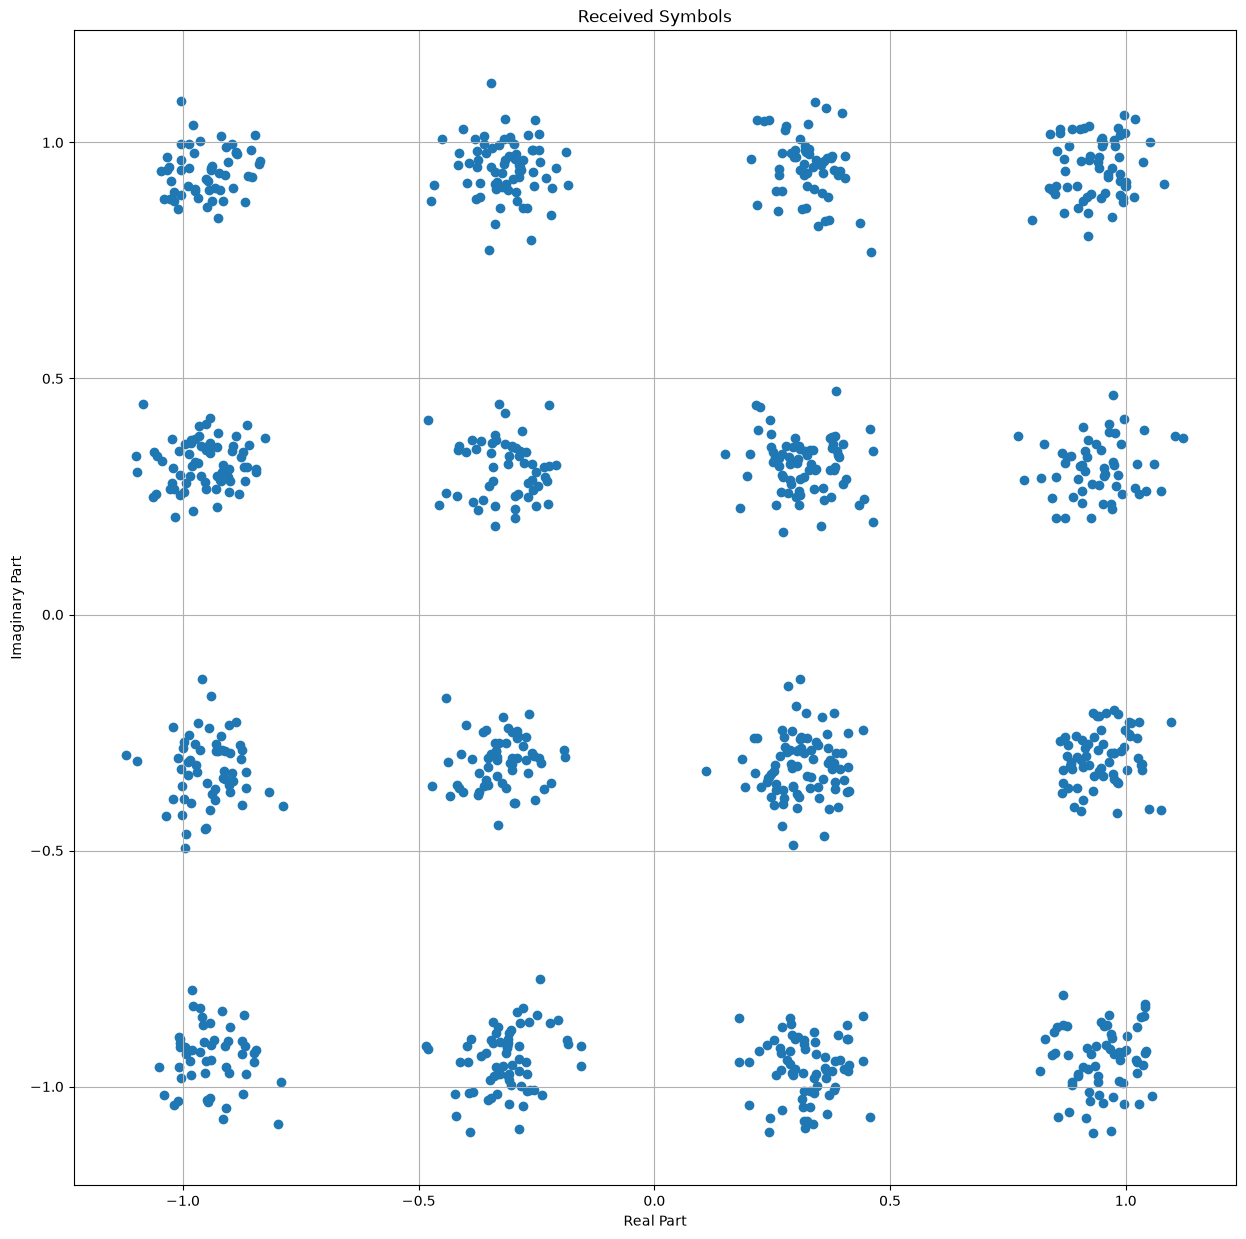

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(111)
plt.scatter(np.real(y), np.imag(y));
ax.set_aspect("equal", adjustable="box")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")
plt.grid(True, which="both", axis="both")
plt.title("Received Symbols");